<a href="https://colab.research.google.com/github/spandana-aithal/Machine-Learning/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

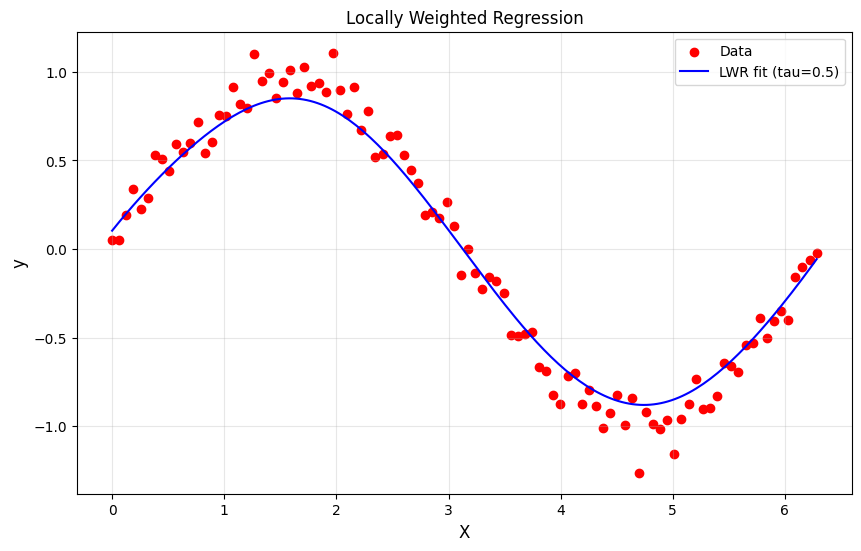

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi)**2) / (2 * tau**2))
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    XTW = X.T @ W
    theta = np.linalg.inv(XTW @ X) @ XTW @ y
    return x @ theta
np.random.seed(42)
X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)
X_bias = np.c_[np.ones(X.shape[0]), X]
x_test = np.linspace(0, 2*np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape[0]), x_test]
tau = 0.5
y_pred = np.array([
    locally_weighted_regression(x_test_bias[i], X_bias, y, tau)
    for i in range(len(x_test))
])
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Data')
plt.plot(x_test, y_pred, color='blue', label=f'LWR fit (tau={tau})')
plt.xlabel('X',fontsize=12)
plt.ylabel('y',fontsize=12)
plt.title('Locally Weighted Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()